<a href="https://colab.research.google.com/github/3aes-ia/Actividades-Inteligencia-Artificial/blob/main/PIA_RNC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PIA
LMV N4

- Eladio Juvera González 2114783
- Antonio Contreras Luevanos 2115255
- Carlos Alberto Aldana Sandoval 2114989
- Sofía Alejandra Martínez Gómez 1998005
- Héctor Alexander Salazar Martínez 2177985
- Vanessa Mendoza Ramirez 2120827
- Ximena Guedea Saldaña 2177846

In [ ]:
from google.colab import drive
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

In [ ]:
drive.mount('/content/drive')

data_dir = '/content/drive/MyDrive/dataset_skittles'

batch_size = 32
img_height = 96
img_width = 96

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.3,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.3,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print(f"Clases detectadas: {class_names}")

Found 476 files belonging to 6 classes.
Using 334 files for training.
Found 476 files belonging to 6 classes.
Using 142 files for validation.
Clases detectadas: ['Amarillo', 'Fondo', 'Morado', 'Naranja', 'Rojo', 'Verde']


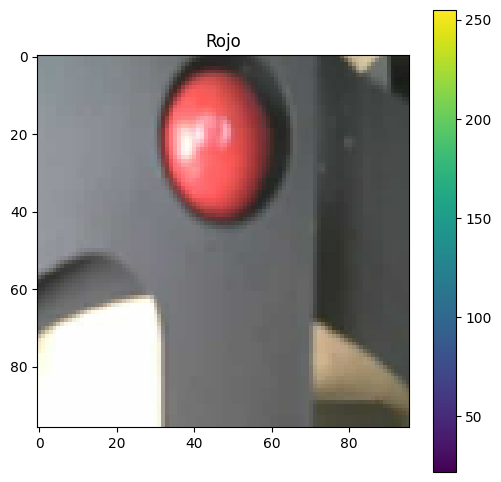

In [ ]:
for images, labels in train_ds.take(1):
    first_image = images[0].numpy().astype("uint8")
    first_label = labels[0].numpy()

    plt.figure(figsize=(6,6))
    plt.imshow(first_image)
    plt.title(f"{class_names[first_label]}")
    plt.colorbar()
    plt.grid(False)
    plt.show()

In [ ]:
def normalize_img(image, label):
  return tf.cast(image, tf.float32) / 255.0, label

train_ds = train_ds.map(normalize_img)
val_ds = val_ds.map(normalize_img)

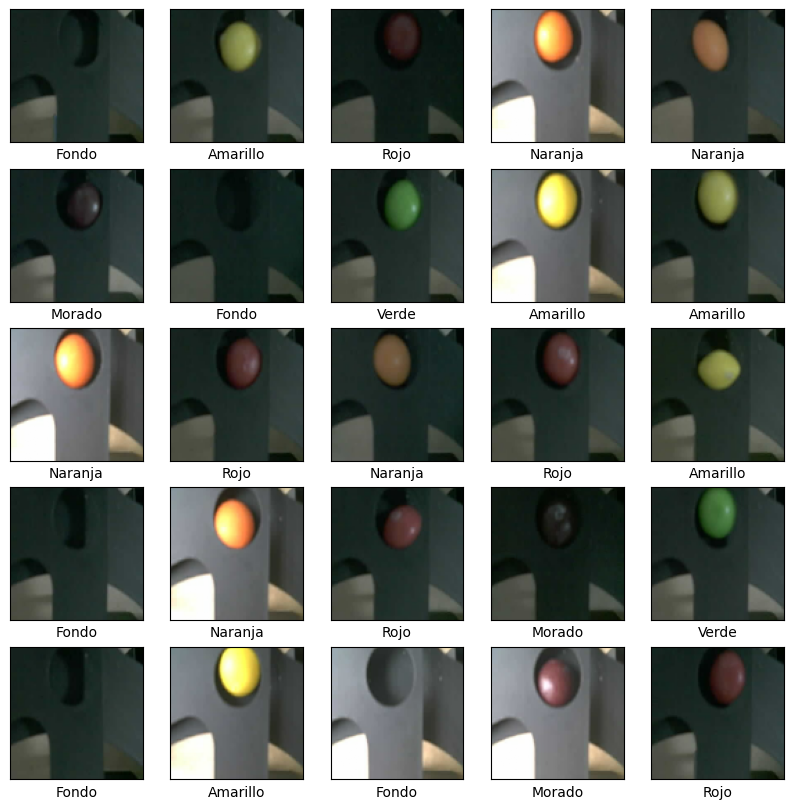

In [ ]:
class_names = ['Amarillo', 'Fondo', 'Morado', 'Naranja', 'Rojo', 'Verde']

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(min(len(images), 25)):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)

        plt.imshow(images[i])

        plt.xlabel(class_names[labels[i]])

plt.show()

In [ ]:
model = models.Sequential()

model.add(layers.Input(shape=(img_height, img_width, 3)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))

model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

In [ ]:
model.summary()

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(6))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 64)     │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.2036 - loss: 1.8434 - val_accuracy: 0.1338 - val_loss: 1.7585
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 781ms/step - accuracy: 0.4401 - loss: 1.5466 - val_accuracy: 0.4296 - val_loss: 1.4013
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 569ms/step - accuracy: 0.6946 - loss: 0.9432 - val_accuracy: 0.6761 - val_loss: 0.6041
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 895ms/step - accuracy: 0.8054 - loss: 0.4569 - val_accuracy: 0.9296 - val_loss: 0.2483
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 605ms/step - accuracy: 0.9790 - loss: 0.1786 - val_accuracy: 0.9577 - val_loss: 0.1533
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 852ms/step - accuracy: 0.9850 - loss: 0.0836 - val_accuracy: 0.9930 - val_loss: 0.0499
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 568ms/step - accuracy: 0.9790 - loss: 0.0738 - val_accuracy: 0.9859 - val_loss: 0.1127
Epoch 8/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 843ms/step - accuracy: 0.9910 - loss: 0.0453 - val_accuracy: 1.

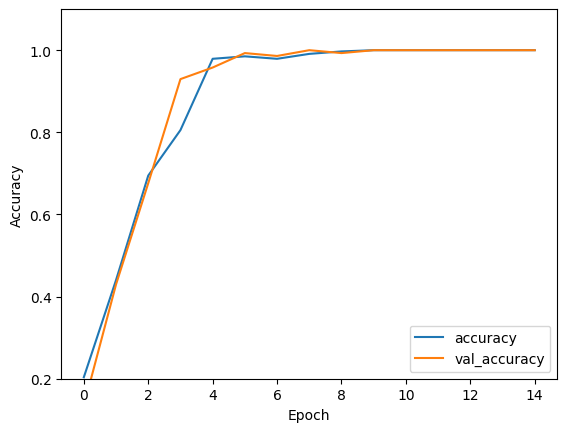

5/5 - 2s - 312ms/step - accuracy: 1.0000 - loss: 0.0019

Precisión final en validación: 100.00%


In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.2, 1.1])
plt.legend(loc='lower right')
plt.show()

test_loss, test_acc = model.evaluate(val_ds, verbose=2)

print(f'\nPrecisión final en validación: {test_acc*100:.2f}%')

In [ ]:
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])

for test_images, test_labels in val_ds.take(1):
    predictions = probability_model.predict(test_images)

    test_images = test_images.numpy()
    test_labels = test_labels.numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step


In [ ]:
def plot_image(i, predictions_array, true_label, img):
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img)

  predicted_label = np.argmax(predictions_array)
  color = 'blue' if predicted_label == true_label else 'red'

  plt.xlabel(f"{class_names[predicted_label]} {100*np.max(predictions_array):2.0f}%\n(Real: {class_names[true_label]})",
             color=color)

def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i]
  plt.grid(False)
  plt.xticks(range(6))
  plt.yticks([])
  thisplot = plt.bar(range(6), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

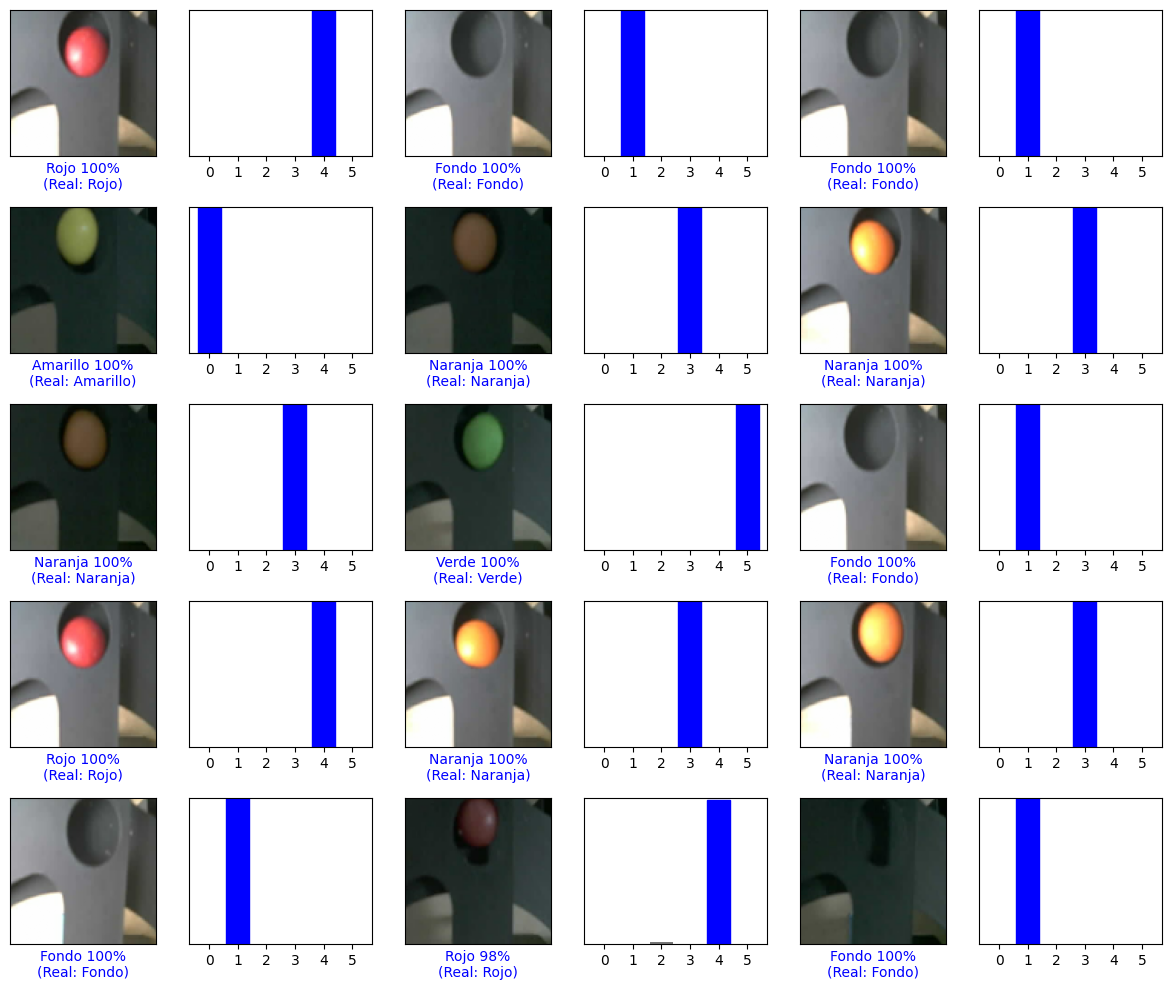

In [ ]:
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))

for i in range(num_images):
  plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
  plot_image(i, predictions[i], test_labels, test_images)
  plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
  plot_value_array(i, predictions[i], test_labels)

plt.tight_layout()
plt.show()

In [ ]:
nombre_archivo = 'modelo_skittles.keras'
model.save(nombre_archivo)

files.download(nombre_archivo)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>